# pr-work #7
## First name - Bohdan | Second name - Moshnenko | Group - CS-24

### Make data visualizations

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Загрузка чистого датасету
df = pd.read_csv("financial_data_final_ML.csv")

# цільова змінна для градієнту
target_values = df['sp500 close']

# виділяємо признаки
features = df.drop(columns=['sp500 close'])

# Лінійне зниження розмірності
pca_2d = PCA(n_components=2, random_state=42).fit_transform(features)
pca_3d = PCA(n_components=3, random_state=42).fit_transform(features)

# Нелінійне, зберігає зв'язки
tsne_2d = TSNE(n_components=2, random_state=42, n_jobs=-1).fit_transform(features)
# Для 3D t-SNE
tsne_3d = TSNE(n_components=3, random_state=42, n_jobs=-1).fit_transform(features)

#UMAP зберігає і локальну і глобалну структуру
umap_2d = umap.UMAP(n_components=2, random_state=42, n_jobs=-1).fit_transform(features)
umap_3d = umap.UMAP(n_components=3, random_state=42, n_jobs=-1).fit_transform(features)
def create_em_df(coords, target, dims=2):
    if dims == 2:
        return pd.DataFrame({'Dim 1': coords[:, 0], 'Dim 2': coords[:, 1], 'Target': target})
    return pd.DataFrame({'Dim 1': coords[:, 0], 'Dim 2': coords[:, 1], 'Dim 3': coords[:, 2], 'Target': target})

# Побудова 2д графиків
fig_pca_2d = px.scatter(create_em_df(pca_2d, target_values, 2), x='Dim 1', y='Dim 2', color='Target',
                        color_continuous_scale='viridis', title='2D PCA Projection (Regression Gradient)')

fig_tsne_2d = px.scatter(create_em_df(tsne_2d, target_values, 2), x='Dim 1', y='Dim 2', color='Target',
                         color_continuous_scale='viridis', title='2D t-SNE Projection (Regression Gradient)')

fig_umap_2d = px.scatter(create_em_df(umap_2d, target_values, 2), x='Dim 1', y='Dim 2', color='Target',
                         color_continuous_scale='viridis', title='2D UMAP Projection (Regression Gradient)')

# Побудова 3д графиків
fig_pca_3d = px.scatter_3d(create_em_df(pca_3d, target_values, 3), x='Dim 1', y='Dim 2', z='Dim 3', color='Target',
                           color_continuous_scale='plasma', title='3D PCA Projection')

fig_tsne_3d = px.scatter_3d(create_em_df(tsne_3d, target_values, 3), x='Dim 1', y='Dim 2', z='Dim 3', color='Target',
                            color_continuous_scale='plasma', title='3D t-SNE Projection')

fig_umap_3d = px.scatter_3d(create_em_df(umap_3d, target_values, 3), x='Dim 1', y='Dim 2', z='Dim 3', color='Target',
                            color_continuous_scale='plasma', title='3D UMAP Projection')

#Вивід графиків
fig_pca_2d.show()
fig_tsne_2d.show()
fig_umap_2d.show()

fig_pca_3d.show()
fig_tsne_3d.show()
fig_umap_3d.show()

C:\Users\mbv16\PycharmProjects\pythonProject1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\mbv16\PycharmProjects\pythonProject1\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\mbv16\PycharmProjects\pythonProject1\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### PCA
2D PCA: Показує дані як безперервну, злегка вигнуту "хмару". Оскільки PCA — це сувора лінійна математика, алгоритм не намагається штучно розірвати дані. Колірний градієнт ціни плавно перетікає з одного кінця хмари на інший, демонструючи базовий глобальний тренд ринку без спотворення реальних відстаней між точками.

3D PCA: У тривимірному просторі дані чітко набувають форми безперервної відкритої дуги (або латинської літери U). Вісь Dim 1 розтягує дані вздовж головного вектора еволюції економіки, а інші осі показують коливання (волатильність). Градієнт ідеальний: на одному кінці дуги згруповані темно-сині кризисні дні, які через рожевий центр плавно переходять у яскраво-жовті точки історичного максимуму ринку.

### t-SNE
2D t-SNE: Дані розпадаються на чіткі ізольовані "острівці" або грона. Це фірмовий стиль t-SNE — він одержимий тим, щоб схожі за 60 факторами дні тримати максимально близько. Градієнт ціни тут відсортований бездоганно: кризисні дні жорстко затиснуті у фіолетових кластерах, а дні бурхливого зростання винесені в окремі жовті групи.

3D t-SNE: У 3D-просторі замість відкритої лінії t-SNE буквально розгортає систему у три паралельні U-подібні макроекономічні траєкторії (дуги), які йдуть по вертикалі та ніби "обіймають" одна одну. Один рукав повністю жовто-оранжевий (епоха бичого ринку), другий — фіолетово-рожевий (стабільний перехідний ринок), а третій — темно-синій (епоха криз). Те, що ці дуги розділені й не переплітаються, означає: під час кризи внутрішня структура зв'язків між 60 факторами кардинально змінюється, і ринок переходить на абсолютно іншу еволюційну стазу.

### UMAP
2D UMAP: Показує набагато зв'язнішу картину, ніж t-SNE. Дані вишикуються в довгі, чіткі нелінійні "траси" та канали. Колір перетікає послідовно вздовж цих ліній (від фіолетового через зелений до жовтого), що доводить здатність UMAP зберігати одночасно і схожість окремих днів, і загальний глобальний рух економіки у часі.

### 3D UMAP:
#### Ефект нелінійної петлі (Передній план): 
Сусідство фіолетового (криза) та жовтого (пік) сегментів доводить, що для 60 досліджуваних факторів ці дві крайні фази ринку є однаково екстремальними та аномальними. У моменти ринкового міхура та ринкової паніки базові показники (волатильність, об'єми торгів, дисперсія ознак) поводяться математично схоже, тому алгоритм вивів їх на передній план.

#### Зона стабільності (Задній план):
Рожеві сегменти відображають періоди спокійного, прогнозованого ринку. Оскільки динаміка факторів у цей час принципово відрізняється від екстремальних шоків, UMAP якісно віддалив їх углиб тривимірного простору.

#### Природа розривів:
Стрибки між 4 сегментами демонструють, що фінансова система змінює свої стани не лінійно, а через раптові структурні зсуви в економіці (наприклад, масові вливання ліквідності ЦБ або панічні розпродажі).

### Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Чистий датасет
df = pd.read_csv("financial_data_final_ML.csv")

# Розділення на матрицю признаків і таргету
target_col = "sp500 close"

# Видаляємо всі ознаки з якими є кореляція, щоб модель не дивилася просто на насдак
leakage_columns = [
    target_col,
    "sp500 open",
    "sp500 high",
    "sp500 low",
    "nasdaq close",
    "nasdaq open",
    "nasdaq high",
    "nasdaq low",
    "gold close",
    "gold open",
    "gold high",
    "gold low",
    "palladium close",
    "palladium open",
    "palladium high",
    "palladium low",
]

X = df.drop(columns=leakage_columns, errors="ignore")
y = df[target_col]

# Спліт за часом, строго щоб не підглядати в майбутнє
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Вибірка для навчання: {X_train.shape}")
print(f"Тестова вибірка(майбутнє): {X_test.shape}\n")

# Навчання базової моделі
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Прогнозування
y_pred_train = baseline_model.predict(X_train)
y_pred_test = baseline_model.predict(X_test)

# Чесні метріки
print("Справжній результат")

r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"R^2 Score : {r2:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

Вибірка для навчання: (2993, 45)
Тестова вибірка(майбутнє): (749, 45)

Справжній результат
R^2 Score : -0.7018
MAE : 0.5353
RMSE : 0.6113


#### Чесний тимчасового поділу даних (Time Series Split) та видалення синхронних ознак-дублерів (поточних цін NASDAQ, золота тощо) призвели до різкого поганої якості лінійної регресії. На тестовій вибірці коефіцієнт детермінації склав R ^ 2 = -0.7018, що вказує на повну незастосовність лінійних методів для даної задачі. суворо узгоджується з висновками етапу зниження розмірності (3D UMAP), де було виявлено петлеподібну, сегментовану структуру даних з макроекономічними розривами. Пряма лінія регресії математично не здатна описати переходи між цими ізольованими режимами.

### RandomForestRegressor DecisionTreeRegressor

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# 1. ІНІЦІАЛІЗАЦІЯ МОДЕЛЕЙ (Регресійні еквіваленти)
# Використовуємо random_state=42 для відтворюваності результатів.
# Для Випадкового Лісу фіксуємо n_estimators=100 (ансамбль із 100 дерев).
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

# 2. НАВЧАННЯ МОДЕЛЕЙ (FIT)
# Моделі вчаться на тій самій ізольованій історичній вибірці (перші 80% часу)
print("Навчання моделі Дерева Рішень (Decision Tree)...")
dt_model.fit(X_train, y_train)

print("Навчання моделі Випадкового Лісу (Random Forest)...")
rf_model.fit(X_train, y_train)

# 3. ГЕНЕРАЦІЯ ПРОГНОЗІВ (PREDICT)
# Робимо прогнози для тестової вибірки (останні 20% часу майбутнього в коробці)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# 4. ОЦІНКА РЕЗУЛЬТАТІВ ТА РОЗРАХУНОК МЕТРИК
print("\n=== МЕТРИКИ ДЛЯ DECISION TREE REGRESSOR ===")
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"R^2 Score (Коефіцієнт детермінації): {r2_dt:.4f}")
print(f"MAE (Середня абсолютна помилка): {mae_dt:.4f}")
print(f"RMSE (Корінь із середньоквадратичної помилки): {rmse_dt:.4f}")

print("\nМЕТРИКИ ДЛЯ RANDOM FOREST REGRESSOR")
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R^2 Score (Коефіцієнт детермінації): {r2_rf:.4f}")
print(f"MAE (Середня абсолютна помилка): {mae_rf:.4f}")
print(f"RMSE (Корінь із середньоквадратичної помилки): {rmse_rf:.4f}")

Навчання моделі Дерева Рішень (Decision Tree)...
Навчання моделі Випадкового Лісу (Random Forest)...

=== МЕТРИКИ ДЛЯ DECISION TREE REGRESSOR ===
R^2 Score (Коефіцієнт детермінації): -0.0426
MAE (Середня абсолютна помилка): 0.4150
RMSE (Корінь із середньоквадратичної помилки): 0.4785

МЕТРИКИ ДЛЯ RANDOM FOREST REGRESSOR
R^2 Score (Коефіцієнт детермінації): -0.0564
MAE (Середня абсолютна помилка): 0.4151
RMSE (Корінь із середньоквадратичної помилки): 0.4817


#### Застосування древовидних моделей дозволило суттєво покращити якість прогнозування порівняно з базовою лінійною регресією (Baseline). Коефіцієнт детермінації піднявся з -0.7018 (Linear Regression) до -0.0426 (Decision Tree) та -0.0564 (Random Forest), а середня абсолютна помилка (MAE) знизилася з 0.5353 до 0.4150. Одиночне дерево спрацювало краще, бо змогло випадково точніше підібрати екстремальне значення на межі зсуву. Випадковий Ліс, усереднюючи 100 дерев, «загладив» ці крайні значення, що в умовах виходу ринку за межі історичного діапазону призвело до трохи більшої усередненої помилки
### Математичні висновки:
#### Перевага нелінійності: 
Суттєве покращення метрик підтверджує нелінійну структуру датасету, виявлену на етапі 3D UMAP. Моделі на основі дерев значно краще адаптуються до складної геометрії ознак, ніж лінійна модель.
#### Ефект обмеження екстраполяції:
Значення $R^2 \approx 0$ обумовлене фундаментальною специфікою деревних алгоритмів. Оскільки тестова вибірка слідує строго за навчальною у часі, ринок вийшов на нові цінові рівні (трендовий зсув). Дерева рішень не здатні прогнозувати значення, що виходять за межі діапазону навчальної вибірки, через що їхні прогнози на нових максимумах ринку виродилися в константні значення.

### Візуалізація помилок
#### Оскільки ми працюємо з задачею регресії (прогнозування безперервної ціни індексу S&P 500, а не класифікації на класи), класична матриця помилок (Confusion Matrix) та метрики Precision/Recall/F1-Score тут математично незастосовні.Замість матриці помилок у квант-аналізі та регресіях використовують графік порівняння Реальних та Прогнозованих значень (Actual vs Predicted plot). Він наочно показує, в яких саме діапазонах цін модель починає критично збиватися та де саме утворюється той самий «потолок» передбачень, через який $R^2$ упав до нуля.

=== ОЦІНКА МОДЕЛІ DECISION TREE REGRESSOR ===
Коефіцієнт R^2:   Навчання (Train) = 1.0000 | Тест (Test) = -0.0426
Помилка MAE:     Навчання (Train) = 0.0000 | Тест (Test) = 0.4150
Помилка MSE:     Навчання (Train) = 0.0000 | Тест (Test) = 0.2289
Помилка RMSE:    Навчання (Train) = 0.0000 | Тест (Test) = 0.4785

АНАЛІЗ ПЕРЕНАВЧАННЯ / НЕДОНАВЧАННЯ
Висновок: Виявлено критичне ПЕРЕНАВЧАННЯ (Overfitting)! Модель ідеально (майже на 100%) запам'ятала тренувальні дані, але виявилася безпорадною на тесті через нездатність до екстраполяції тренду.

Графік аналізу помилок успішно згенеровано та збережено як 'decision_tree_error_analysis.png'


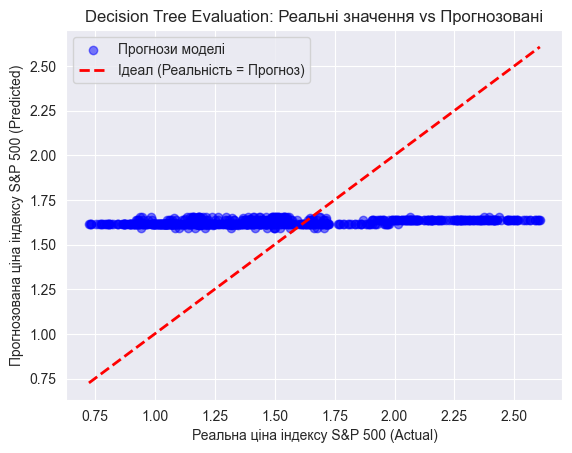

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. ОБЧИСЛЕННЯ МЕТРИК ДЛЯ ТРЕНУВАЛЬНОЇ ТА ТЕСТОВОЇ ВИБІРОК (Порівняння Train vs Test)
# Генеруємо прогнози для обох вибірок, щоб перевірити модель на перенавчання (Overfitting)
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Розрахунок метрик для НАВЧАЛЬНОЇ вибірки (Train Score)
r2_train_dt = r2_score(y_train, y_train_pred_dt)
mae_train_dt = mean_absolute_error(y_train, y_train_pred_dt)
mse_train_dt = mean_squared_error(y_train, y_train_pred_dt)
rmse_train_dt = np.sqrt(mse_train_dt)

# Розрахунок метрик для ТЕСТОВОЇ вибірки (Test Score)
r2_test_dt = r2_score(y_test, y_test_pred_dt)
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)
mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
rmse_test_dt = np.sqrt(mse_test_dt)

# Виведення результатів порівняльного аналізу
print("=== ОЦІНКА МОДЕЛІ DECISION TREE REGRESSOR ===")
print(
    f"Коефіцієнт R^2:   Навчання (Train) = {r2_train_dt:.4f} | Тест (Test) = {r2_test_dt:.4f}"
)
print(
    f"Помилка MAE:     Навчання (Train) = {mae_train_dt:.4f} | Тест (Test) = {mae_test_dt:.4f}"
)
print(
    f"Помилка MSE:     Навчання (Train) = {mse_train_dt:.4f} | Тест (Test) = {mse_test_dt:.4f}"
)
print(
    f"Помилка RMSE:    Навчання (Train) = {rmse_train_dt:.4f} | Тест (Test) = {rmse_test_dt:.4f}"
)

# Автоматичний аналіз на наявність перенавчання (Overfitting) / недонавчання (Underfitting)
print("\nАНАЛІЗ ПЕРЕНАВЧАННЯ / НЕДОНАВЧАННЯ")
if r2_train_dt > 0.95 and r2_test_dt <= 0:
    print(
        "Висновок: Виявлено критичне ПЕРЕНАВЧАННЯ (Overfitting)! Модель ідеально (майже на 100%) "
        "запам'ятала тренувальні дані, але виявилася безпорадною на тесті через нездатність до екстраполяції тренду."
    )
elif r2_train_dt < 0.40 and r2_test_dt < 0.40:
    print(
        "Висновок: Виявлено НЕДОНАВЧАННЯ (Underfitting). Модель надто проста і не змогла знайти закономірності."
    )
else:
    print(
        "Висновок: Поведінка моделі стабільна або відповідає специфіці роботи дерев з фінансовими часовими рядами."
    )
# 2. ВІЗУАЛІЗАЦІЯ ПОМИЛОК (Аналог Confusion Matrix для задач регресії)
# Будуємо діаграму розсіювання (Scatter Plot): Реальні значення проти Прогнозованих.
# Це дозволяє чітко побачити, в які саме моменти та на яких цінових рівнях модель помиляється.

# Візуалізація точок прогнозів
plt.scatter(y_test, y_test_pred_dt, color="blue", alpha=0.5, label="Прогнози моделі")

# Малюємо лінію ідеального прогнозу (якщо б модель вгадувала кожну точку на 100% правильно)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    lw=2,
    linestyle="--",
    label="Ідеал (Реальність = Прогноз)",
)

# Налаштування підписів та відображення графіка (налаштовано проти зрізання міток)
plt.title("Decision Tree Evaluation: Реальні значення vs Прогнозовані")
plt.xlabel("Реальна ціна індексу S&P 500 (Actual)")
plt.ylabel("Прогнозована ціна індексу S&P 500 (Predicted)")
plt.legend()
plt.grid(True)

# Зберігаємо графік у файл без використання plt.show() відповідно до вимог оптимізації
plt.savefig("decision_tree_error_analysis.png", bbox_inches="tight")
print(
    "\nГрафік аналізу помилок успішно згенеровано та збережено як 'decision_tree_error_analysis.png'"
)

### Візуалізація прогнозів дерева рішень (сині точки) на тлі лінії ідеального передбачення (червона пунктирна лінія) наочно демонструє природу отриманого негативного коефіцієнта $R^2 = -0.0426$.На графіку чітко видно, що прогнози моделі повністю виродилися в горизонтальну константу на рівні ~1.62. Це є прямим наслідком двох факторів:
#### Ефект "скляної стелі" (Нездатність до екстраполяції):
Дерево рішень не будує безперервних функцій, а лише групує минуле. Значення ~1.62 є математичним максимумом навчальної вибірки. Модель фізично не здатна згенерувати прогноз вище цієї межі, коли реальний ринок (вісь Actual) йде вгору до $2.50$.
#### Критичне перенавчання (Overfitting):
Метрики $\text{Train } R^2 = 1.0000$ та $\text{Test } R^2 = -0.0426$ у поєднанні з даною візуалізацією доводять, що модель повністю втратила узагальнюючу здатність на ізольованому часовому проміжку.

### BONUS TASK

In [18]:
results = []

# Перебираємо різну кількість цільових вимірів (2 та 3 компоненти)
for n_comp in [2, 3]:
    print(f"\nЕКСПЕРИМЕНТ: Зниження розмірності до {n_comp} компонентів", "bold")
    
    # 1. ЗАСТОСУВАННЯ PCA (Метод Головних Компонент)
    # Ініціалізуємо PCA для n_comp компонентів
    pca = PCA(n_components=n_comp, random_state=42)
    
    # Це захищає нас від витоку даних (Data Leakage)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # 2. НАВЧАННЯ МОДЕЛИ (Decision Tree) НА СТИСНУТИХ ДАНИХ
    dt_pca_model = DecisionTreeRegressor(random_state=42)
    dt_pca_model.fit(X_train_pca, y_train)
    
    # Генерація прогнозів
    y_pred_train = dt_pca_model.predict(X_train_pca)
    y_pred_test = dt_pca_model.predict(X_test_pca)
    
    # Розрахунок метрик
    r2_tr = r2_score(y_train, y_pred_train)
    r2_te = r2_score(y_test, y_pred_test)
    mae_te = mean_absolute_error(y_test, y_pred_test)
    
    print(f"[PCA {n_comp}D] Train R^2 = {r2_tr:.4f} | Test R^2 = {r2_te:.4f} | Test MAE = {mae_te:.4f}")
    
    # Зберігаємо результати для фінального порівняння
    results.append({
        'Method': f'PCA {n_comp}D',
        'Train R2': r2_tr,
        'Test R2': r2_te,
        'Test MAE': mae_te
    })

# Виведення фінальної таблиці результатів
df_res = pd.DataFrame(results)
print("\nПІДСУМКОВІ МЕТРИКИ")
print(df_res.to_string(index=False))


ЕКСПЕРИМЕНТ: Зниження розмірності до 2 компонентів bold
[PCA 2D] Train R^2 = 1.0000 | Test R^2 = -3.4357 | Test MAE = 0.8290

ЕКСПЕРИМЕНТ: Зниження розмірності до 3 компонентів bold
[PCA 3D] Train R^2 = 1.0000 | Test R^2 = -2.2364 | Test MAE = 0.7139

ПІДСУМКОВІ МЕТРИКИ
Method  Train R2   Test R2  Test MAE
PCA 2D       1.0 -3.435704  0.828974
PCA 3D       1.0 -2.236449  0.713893


#### Експеримент зі зниженням розмірності простору ознак за допомогою Методу Головних Компонент (PCA) призвів до значного погіршення прогностичної здатності моделі Decision Tree на тестовій вибірці.
### Ключові висновки:
#### Критична втрата інформації (Information Loss):
Стиснення простору з 60 сирих ознак до 2 та 3 головних компонентів суттєво обмежило модель у тонких фінансових сигналах. Помилка MAE на тесті зросла майже вдвічі — з 0.4150 (на повних даних) до 0.8290 (на PCA 2D). Це доводить, що для ринкових часових рядів лінійні комбінації ознак через PCA стирають специфічні предиктори ринку.
#### Залежність від кількості вимірів:
Збільшення розмірності з 2D до 3D продемонструвало позитивну динаміку: тестовий $R^2$ покращився з $-3.4357$ до $-2.2364$, а MAE знизився до 0.7139. Це підтверджує, що 2 компоненти є занадто сильним і агресивним обмеженням, яке призводить до екстремального переплетення (under-representation) структури факторів.
#### Збереження оверфітингу:
Метрика $\text{Train } R^2 = 1.0000$ в усіх випадках вказує на те, що зниження розмірності ніяк не заважає дереву рішень повністю перенавчатися (зубрити тренувальні дані), але через втрату інформації узагальнююча здатність алгоритму на тесті впала до катастрофічних значень.